In [1]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Drive path (for Colab)
file_path = "/content/drive/MyDrive/Data/Regional-concentration-analysis-of-foreign-tourists/data/shukuhaku_prefecture2025.xlsx"

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

['統計表（目次）', '第1表(1月)', '第1表(2月)', '第1表(3月)', '第1表(4月)', '第1表(5月)', '第1表(6月)', '第1表(7月)', '第1表(8月)', '第1表(9月)', '第1表(10月)', '第1表(11月)', '第1表(12月)', '第2表(年計)', '第2表(1月)', '第2表(2月)', '第2表(3月)', '第2表(4月)', '第2表(5月)', '第2表(6月)', '第2表(7月)', '第2表(8月)', '第2表(9月)', '第2表(10月)', '第2表(11月)', '第2表(12月)', '第3表(年計)', '第3表(1月)', '第3表(2月)', '第3表(3月)', '第3表(4月)', '第3表(5月)', '第3表(6月)', '第3表(7月)', '第3表(8月)', '第3表(9月)', '第3表(10月)', '第3表(11月)', '第3表(12月)', '第4表(年計)', '第4表(1月)', '第4表(2月)', '第4表(3月)', '第4表(4月)', '第4表(5月)', '第4表(6月)', '第4表(7月)', '第4表(8月)', '第4表(9月)', '第4表(10月)', '第4表(11月)', '第4表(12月)', '第5表(年計)', '第5表(1月)', '第5表(2月)', '第5表(3月)', '第5表(4月)', '第5表(5月)', '第5表(6月)', '第5表(7月)', '第5表(8月)', '第5表(9月)', '第5表(10月)', '第5表(11月)', '第5表(12月)', '第6表(年計)', '第6表(1月)', '第6表(2月)', '第6表(3月)', '第6表(4月)', '第6表(5月)', '第6表(6月)', '第6表(7月)', '第6表(8月)', '第6表(9月)', '第6表(10月)', '第6表(11月)', '第6表(12月)', '第7表(年計)', '第7表(1月)', '第7表(2月)', '第7表(3月)', '第7表(4月)', '第7表(5月)', '第7表(6月)', '第7表(7月)', '第7表(8月)', '第7表(9月)', '第7表(10月)', '

# 第２表　従業者数(4区分)、宿泊目的割合(2区分)別延べ宿泊者数

In [4]:
%%time

monthly_data = []

cols = ["guest_nights", "foreign_guest_nights"]

for month in range(1,13):

    df = pd.read_excel(
        file_path,
        sheet_name=f"第2表({month}月)",
        header=2
    )

    df_simple = df.iloc[4:, [0,1,16]].copy()
    df_simple.columns = ["prefecture","guest_nights","foreign_guest_nights"]
    df_simple[cols] = df_simple[cols].apply(pd.to_numeric)

    # 都道府県のみ
    df_simple = df_simple.iloc[:47].reset_index(drop=True)

    # 月
    df_simple["month"] = month

    monthly_data.append(df_simple)

df_all = pd.concat(monthly_data, ignore_index=True)

print(df_all.shape)
print(df_all.columns)
df_all.head()

(564, 4)
Index(['prefecture', 'guest_nights', 'foreign_guest_nights', 'month'], dtype='object')
CPU times: user 5min 56s, sys: 783 ms, total: 5min 57s
Wall time: 6min 2s


,prefecture,guest_nights,foreign_guest_nights,month
0,北海道,4167480.0,1991030.0,1
1,青森県,314800.0,47010.0,1
2,岩手県,435710.0,56070.0,1
3,宮城県,704510.0,96050.0,1
4,秋田県,186670.0,12580.0,1


# 都道府県別 外国人延べ宿泊者比率

In [5]:
# 年単位のデータへ
df1 = df_all.groupby("prefecture")[["guest_nights","foreign_guest_nights"]].sum().reset_index()

# 各都道府県における延べ宿泊者数の外国人割合
df1["foreign_ratio"] = df1["foreign_guest_nights"] / df1["guest_nights"]

# 全角スペース削除
df1["prefecture"] = df1["prefecture"].str.replace("\u3000", "").str.strip()

In [6]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 71.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=f818ee677d902ed3c3fbecb556562940e487d0d5360a514825fc522c4f696a09
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


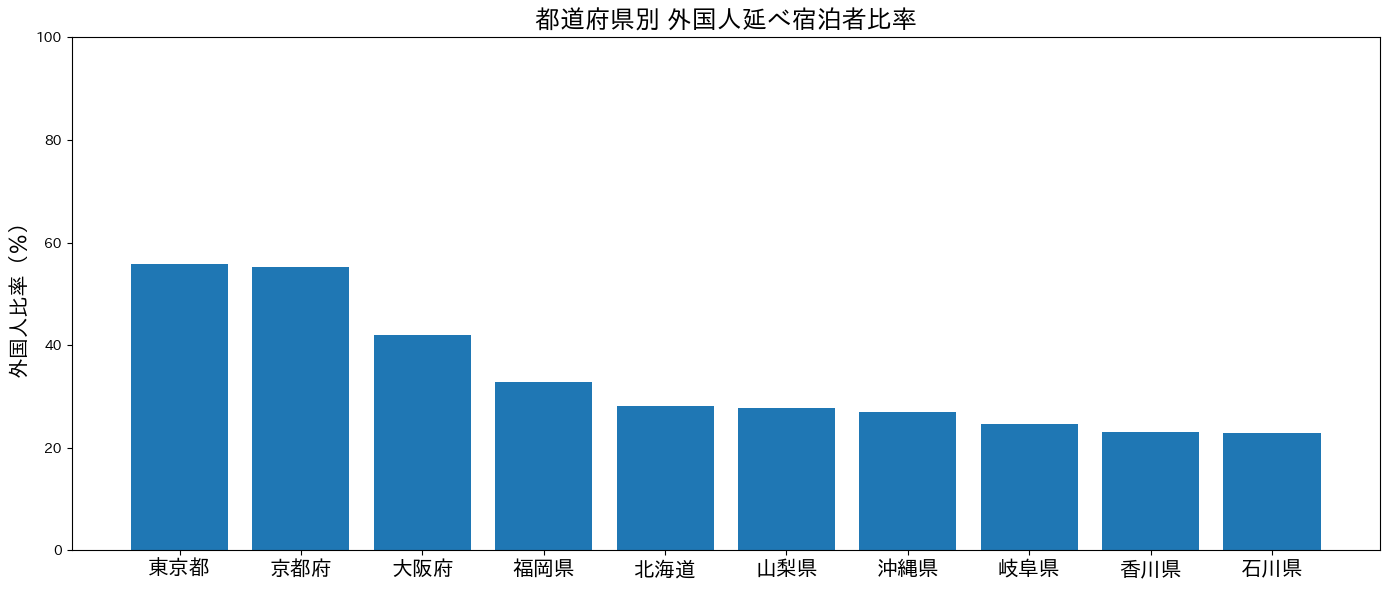

In [7]:
import japanize_matplotlib

df_plot = df1.sort_values("foreign_ratio", ascending=False).head(10)

plt.figure(figsize=(14,6))

plt.bar(
    df_plot["prefecture"],
    df_plot["foreign_ratio"] * 100
)

plt.ylabel("外国人比率（％）", fontsize=15)
plt.title("都道府県別 外国人延べ宿泊者比率", fontsize=18)

plt.ylim(0, 100)

# ラベル回転（これ重要）
plt.xticks(rotation=0, fontsize=15)

plt.tight_layout()
plt.show()

# 都道府県別の延べ宿泊者数の規模（東京を除く上位15）

In [8]:
# 東京の延べ宿泊者数合計
tokyo_value = df1[df1["prefecture"] == "東京都"]["guest_nights"].iloc[0]

# 各都道府県の延べ宿泊者数の規模（東京を100％とした場合）
df1["tourism_scale(%)"] = df1["guest_nights"] / tokyo_value * 100

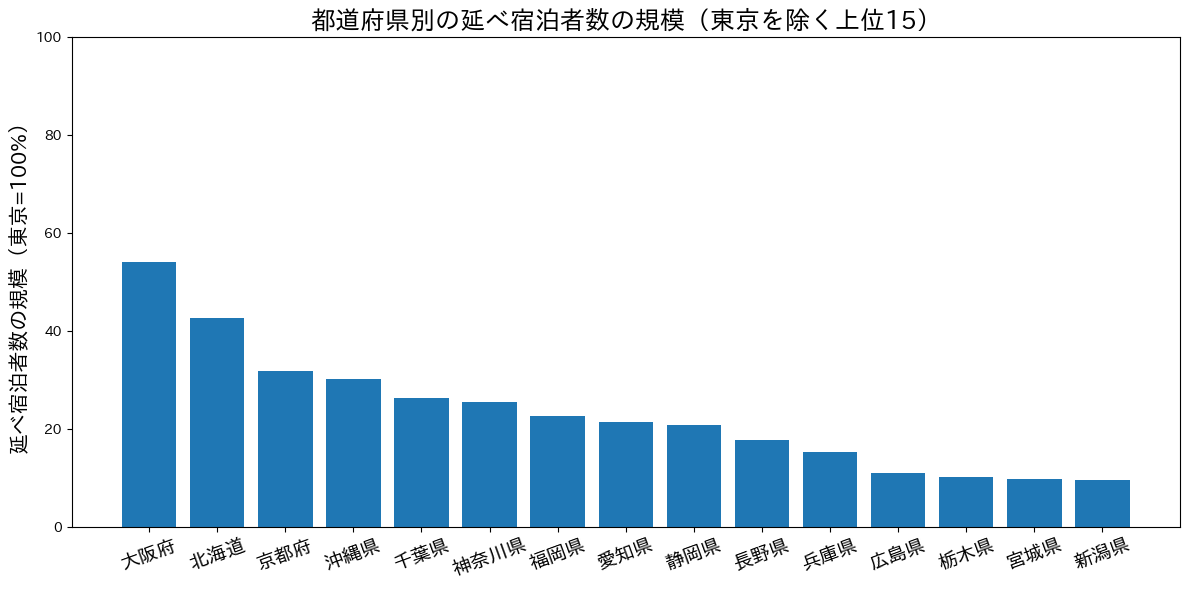

In [9]:
df_plot = df1.sort_values("tourism_scale(%)", ascending=False).iloc[1:16]

plt.figure(figsize=(12,6))

plt.bar(
    df_plot["prefecture"],
    df_plot["tourism_scale(%)"]
)

plt.ylabel("延べ宿泊者数の規模（東京=100%）", fontsize=15)
plt.title("都道府県別の延べ宿泊者数の規模（東京を除く上位15）", fontsize=18)

plt.ylim(0, 100)
plt.xticks(rotation=20, fontsize=14)

plt.tight_layout()
plt.show()

# 参考第１表（外国人延べ宿泊者数（従業者数10人以上の施設））

In [10]:
%%time

# ヘッダーを使わずにそのまま読む
raw = pd.read_excel(
    file_path,
    sheet_name="参考第1表(年計)",
    header=None
)

# 列名を手動で作る
col_names = ["prefecture", "foreign_total"] + raw.iloc[4, 2:].tolist()

# データ本体は Excelの7行目以降
df2 = raw.iloc[6:, :].copy()
df2.columns = col_names

# 最初の行は全国計なので除く
df2 = df2.iloc[1:].reset_index(drop=True)

# 都道府県47件だけ残す
df2 = df2.iloc[:47].copy()

# 数値化したい列
num_cols = df2.columns[1:]
for col in num_cols:
    df2[col] = pd.to_numeric(df2[col], errors="coerce")

display(df2.head())
print(df2.columns.tolist())

,prefecture,foreign_total,韓国,中国,香港,台湾,米国,カナダ,英国,ドイツ,...,タイ,マレーシア,インド,オーストラリア,インドネシア,ベトナム,フィリピン,イタリア,スペイン,その他
0,北海道,11183330,2364820,1992630,657420,2372050,493100,83900,66130,40320,...,503350,302140,22860,313500,150920,22120,184650,16650,11040,658070
1,青森県,486030,42500,86160,35660,167390,40130,4690,5570,3670,...,10480,5590,1260,14390,2740,1190,2240,1730,940,23990
2,岩手県,409620,14100,35470,31710,201890,16980,2980,3810,2980,...,10460,4020,960,19510,2380,2370,810,960,710,20780
3,宮城県,962320,31670,129630,85800,434850,49620,8540,13020,9330,...,33430,13050,2980,16180,6570,3360,2500,3280,2560,62440
4,秋田県,123760,6120,12540,7550,56600,8180,1390,1380,1200,...,2920,1440,250,3490,970,1150,1050,350,340,9460


['prefecture', 'foreign_total', '韓国', '中国', '香港', '台湾', '米国', 'カナダ', '英国', 'ドイツ', 'フランス', 'ロシア', 'シンガポール', 'タイ', 'マレーシア', 'インド', 'オーストラリア', 'インドネシア', 'ベトナム', 'フィリピン', 'イタリア', 'スペイン', 'その他']
CPU times: user 28.2 s, sys: 66.7 ms, total: 28.2 s
Wall time: 28.5 s


# 東京都における国籍別延べ宿泊者数（従業者数10人以上の施設）

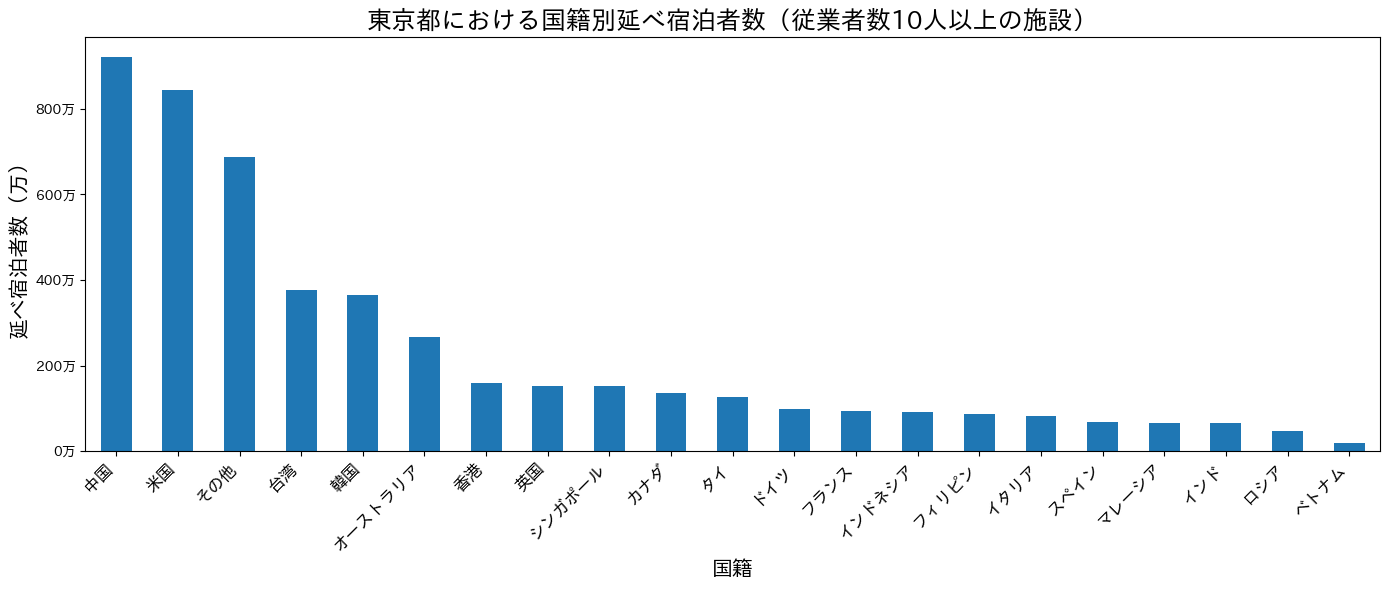

In [11]:
import matplotlib.ticker as mticker

# 東京だけ抽出（空白対策）
tokyo = df2[df2["prefecture"].str.strip() == "東京都"].iloc[0]

# 国別列（prefecture, foreign_total を除く）
country_cols = df2.columns[2:23]

# 国別人数
tokyo_counts = tokyo[country_cols].sort_values(ascending=False)

# グラフ
plt.figure(figsize=(14,6))
tokyo_counts.plot(kind="bar")

plt.title("東京都における国籍別延べ宿泊者数（従業者数10人以上の施設）", fontsize=18)
plt.xlabel("国籍", fontsize=15)

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/10000)}万'))
plt.ylabel("延べ宿泊者数（万）", fontsize=15)

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()

plt.show()

# 国籍別延べ宿泊者割合（従業者数10人以上の施設）

In [12]:
# 国名列だけ取得（prefecture, foreign_total以外）
country_cols = df2.columns[2:]

for col in country_cols:
    df2[col + "_ratio"] = df2[col] / df2["foreign_total"]

df_ratio = pd.concat([df2.iloc[:, [0]], df2.iloc[:, 23:]], axis=1)

# 全角スペース削除
df_ratio["prefecture"] = df_ratio["prefecture"].str.replace("\u3000", "").str.strip()

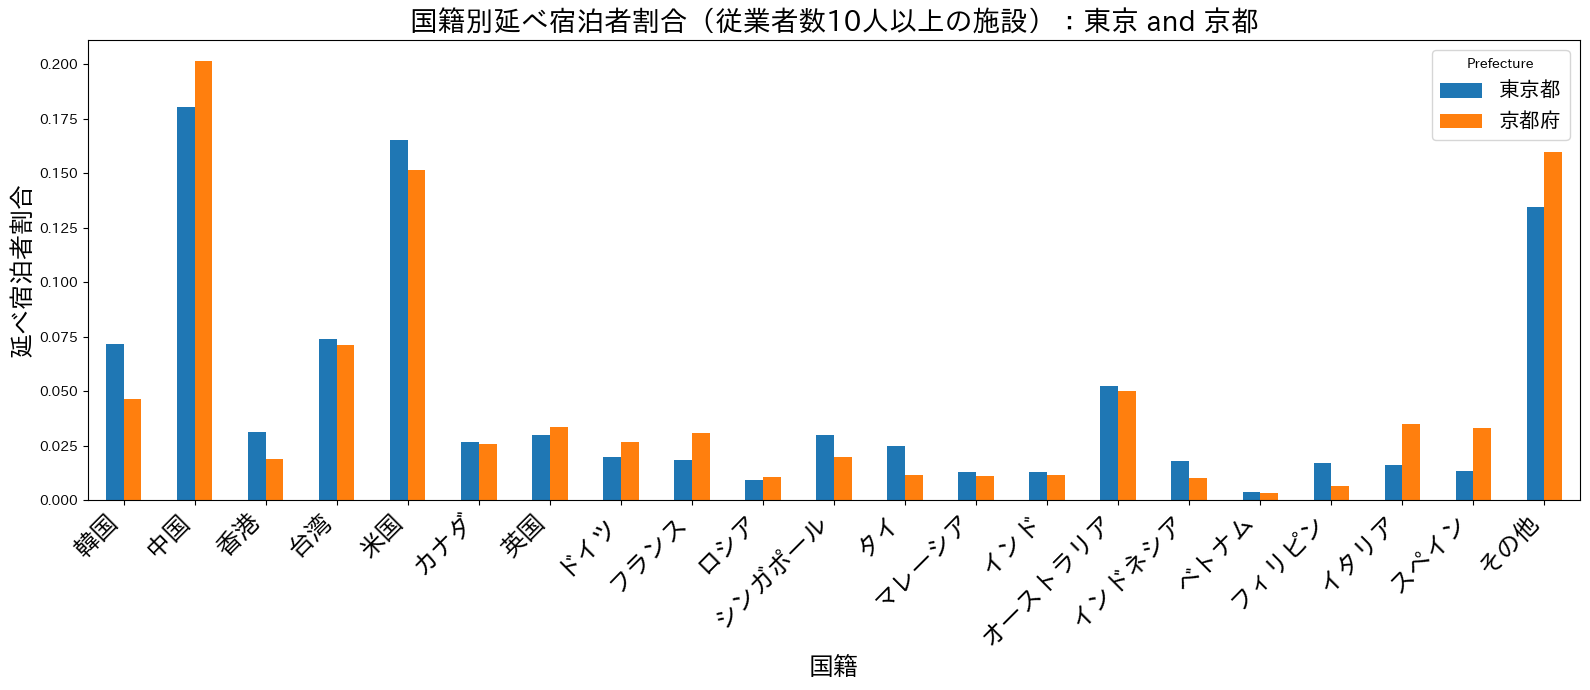

In [43]:
# 比較したい都道府県
target_prefectures = ["東京都", "京都府"]

# ratio列だけ取得（prefecture列は除く）
ratio_cols = [col for col in df_ratio.columns if col != "prefecture" and col.endswith("_ratio")]

# 対象都道府県だけ抽出
plot_df = df_ratio[df_ratio["prefecture"].isin(target_prefectures)].copy()

# prefecture を index に
plot_df = plot_df.set_index("prefecture")

# 国名部分だけに整える（例: 韓国_ratio → 韓国）
plot_df.columns = [col.replace("_ratio", "") for col in plot_df.columns]

# 転置して、国籍を縦軸にしやすくする
plot_df_t = plot_df.T

# グラフ
ax = plot_df_t.plot(kind="bar", figsize=(16, 7))

plt.title("国籍別延べ宿泊者割合（従業者数10人以上の施設）：東京 and 京都", fontsize=20)
plt.xlabel("国籍", fontsize=18)
plt.ylabel("延べ宿泊者割合", fontsize=18)
plt.xticks(rotation=45, ha="right", fontsize=18)
plt.legend(title="Prefecture", fontsize=15)
plt.tight_layout()
plt.show()

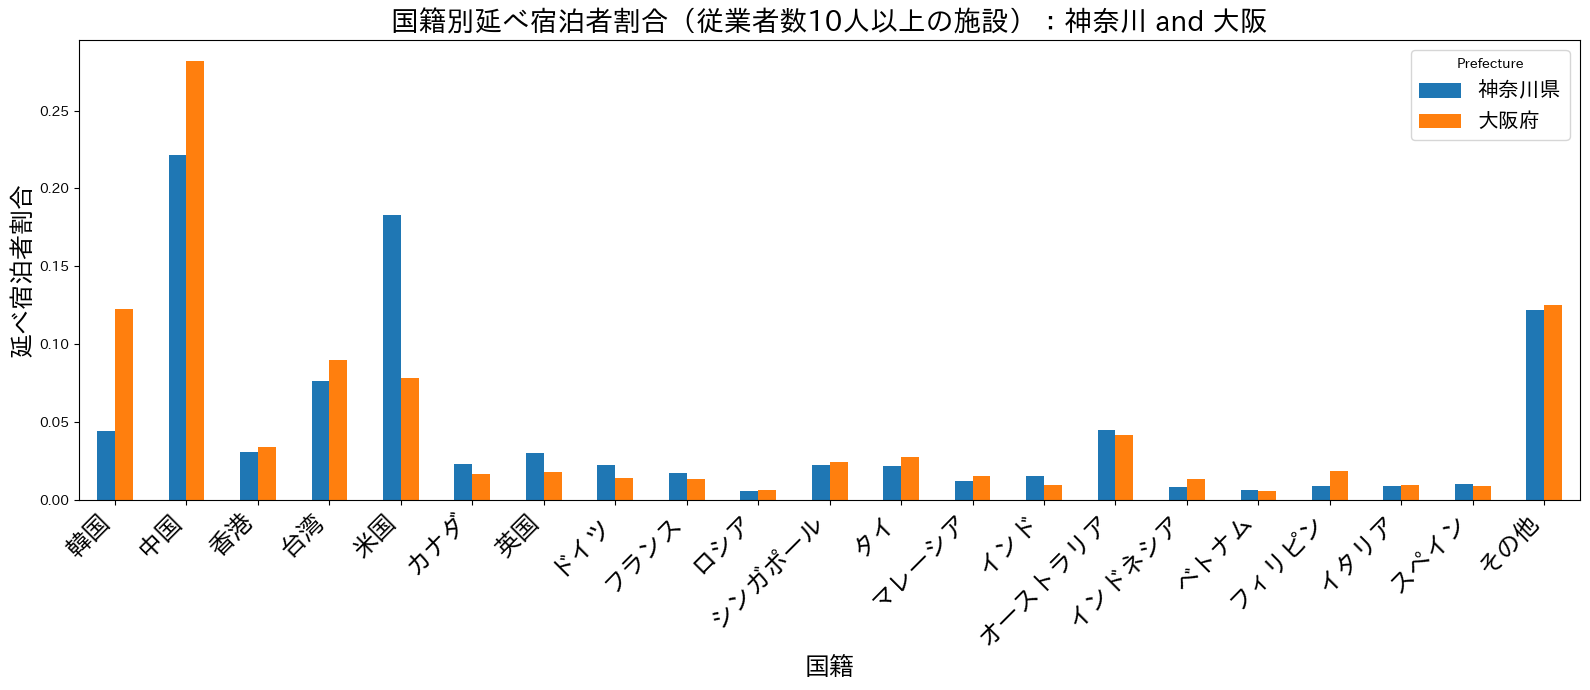

In [13]:
# 比較したい都道府県
target_prefectures = ["大阪府", "神奈川県"]

# ratio列だけ取得（prefecture列は除く）
ratio_cols = [col for col in df_ratio.columns if col != "prefecture" and col.endswith("_ratio")]

# 対象都道府県だけ抽出
plot_df = df_ratio[df_ratio["prefecture"].isin(target_prefectures)].copy()

# prefecture を index に
plot_df = plot_df.set_index("prefecture")

# 国名部分だけに整える（例: 韓国_ratio → 韓国）
plot_df.columns = [col.replace("_ratio", "") for col in plot_df.columns]

# 転置して、国籍を縦軸にしやすくする
plot_df_t = plot_df.T

# グラフ
ax = plot_df_t.plot(kind="bar", figsize=(16, 7))

plt.title("国籍別延べ宿泊者割合（従業者数10人以上の施設）：神奈川 and 大阪", fontsize=20)
plt.xlabel("国籍", fontsize=18)
plt.ylabel("延べ宿泊者割合", fontsize=18)
plt.xticks(rotation=45, ha="right", fontsize=18)
plt.legend(title="Prefecture", fontsize=15)
plt.tight_layout()
plt.show()

# 規模（延べ宿泊者数） × 外国人比率の関係

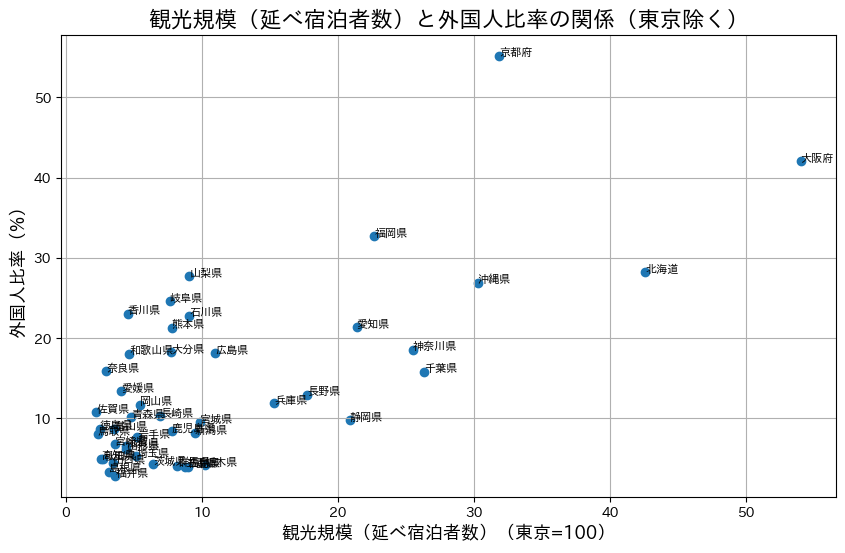

In [23]:
df_plot = df1[df1["prefecture"] != "東京都"]

plt.figure(figsize=(10,6))

plt.scatter(
    df_plot["tourism_scale(%)"],
    df_plot["foreign_ratio"] * 100
)

for i in range(len(df_plot)):
    plt.text(
        df_plot["tourism_scale(%)"].iloc[i],
        df_plot["foreign_ratio"].iloc[i] * 100,
        df_plot["prefecture"].iloc[i],
        fontsize=8
    )

plt.xlabel("観光規模（延べ宿泊者数）（東京=100）", fontsize=13)
plt.ylabel("外国人比率（%）", fontsize=13)
plt.title("観光規模（延べ宿泊者数）と外国人比率の関係（東京除く）", fontsize=16)

plt.grid(True)
plt.show()

In [24]:
# 相関係数
df_plot = df1[df1["prefecture"] != "東京都"]

corr = df_plot["tourism_scale(%)"].corr(df_plot["foreign_ratio"])
print(corr)

0.7040131698978125


In [16]:
# クラスタリング
from sklearn.cluster import KMeans

# データ作成
X = df_plot[["tourism_scale(%)", "foreign_ratio"]]

# モデル
kmeans = KMeans(n_clusters=3, random_state=42)
df_plot["cluster"] = kmeans.fit_predict(X)

/tmp/ipykernel_2927/441918498.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["cluster"] = kmeans.fit_predict(X)


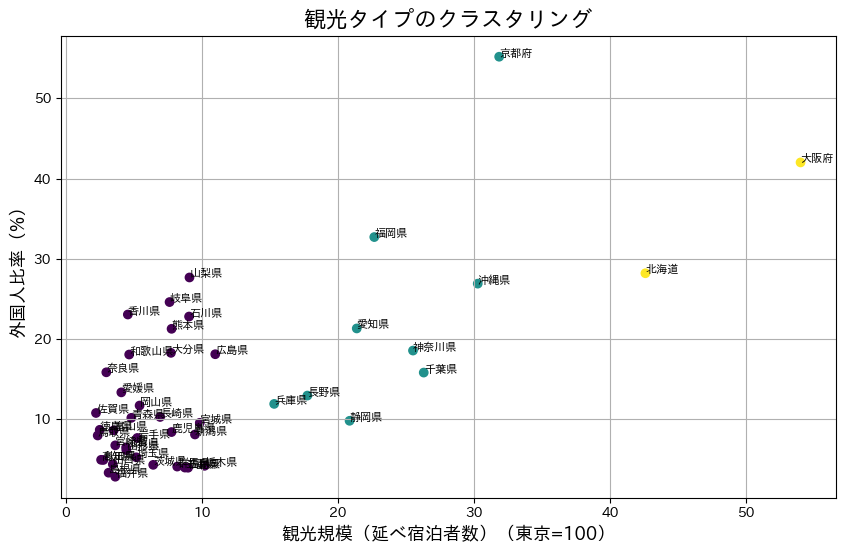

In [17]:
# 可視化
plt.figure(figsize=(10,6))

plt.scatter(
    df_plot["tourism_scale(%)"],
    df_plot["foreign_ratio"] * 100,
    c=df_plot["cluster"]
)

for i in range(len(df_plot)):
    plt.text(
        df_plot["tourism_scale(%)"].iloc[i],
        df_plot["foreign_ratio"].iloc[i] * 100,
        df_plot["prefecture"].iloc[i],
        fontsize=8
    )

plt.xlabel("観光規模（延べ宿泊者数）（東京=100）", fontsize=13)
plt.ylabel("外国人比率（%）", fontsize=13)
plt.title("観光タイプのクラスタリング", fontsize=16)

plt.grid(True)
plt.show()

In [18]:
df_plot.groupby("cluster")[["tourism_scale(%)", "foreign_ratio"]].mean()

,tourism_scale(%),foreign_ratio
cluster,,
0,5.831570,0.106020
1,23.536885,0.228065
2,48.288271,0.351133


###cluster 0
- 規模：5.8（かなり小さい）
- 外国人比率：10.6%

👉 小規模 × 低インバウンド → 地方・国内観光中心

###cluster 1
- 規模：23.5（中規模）
- 外国人比率：22.8%

👉 中規模 × 中インバウンド → 地方拠点・バランス型（京都・福岡・愛知・神奈川・千葉など）

###cluster 2
- 規模：48.3（かなり大きい）
- 外国人比率：35.1%

👉 大規模 × 高インバウンド → 都市型（大阪・北海道）

###結論
👉 スケールに応じてインバウンド比率が上がる

ただし

山梨・岐阜（規模は小さいが、外国人割合が20％以上）

のように、観光規模は小さいが、外国人観光客が集まる地域もある

# 国籍構成 × 外国人比率（どの国の比率が高いと、外国人比率が上がるか）

In [19]:
# 各国籍の割合と foreign_ratio の相関を見る。

# df1から必要な列だけ取り出す
df_merge = df_ratio.merge(
    df1[["prefecture", "foreign_ratio"]],
    on="prefecture",
    how="left"
)

# 国籍カラムだけ抽出（_ratioがついてる列）
country_cols = [col for col in df_merge.columns if "_ratio" in col]

corrs = {}
for col in country_cols:
    corrs[col] = df_merge[col].corr(df_merge["foreign_ratio"])

df_corr = pd.DataFrame.from_dict(corrs, orient="index", columns=["correlation"])
df_corr = df_corr.sort_values("correlation", ascending=False)

df_corr

,correlation
foreign_ratio,1.000000
カナダ_ratio,0.414251
スペイン_ratio,0.399385
イタリア_ratio,0.362321
米国_ratio,0.333716
フィリピン_ratio,0.322858
英国_ratio,0.270382
その他_ratio,0.267063
オーストラリア_ratio,0.244574
ロシア_ratio,0.243407


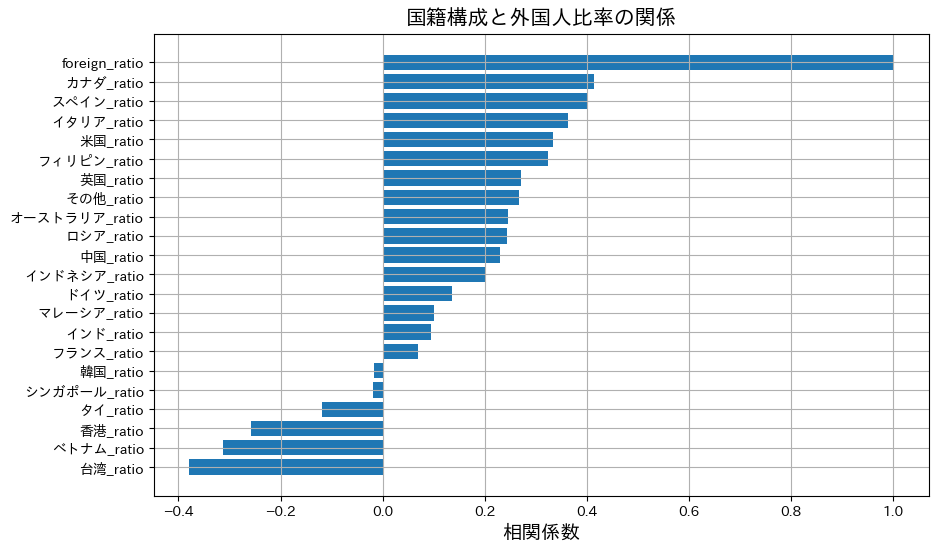

In [20]:
plt.figure(figsize=(10,6))

plt.barh(
    df_corr.index,
    df_corr["correlation"]
)

plt.xlabel("相関係数", fontsize=14)
plt.title("国籍構成と外国人比率の関係", fontsize=15)

plt.gca().invert_yaxis()
plt.grid(True)

plt.show()

###正の相関（外国人比率が高い地域ほど多い国籍）
- カナダ（≈0.4）
- スペイン
- イタリア
- アメリカ
- フィリピン
- 英国

###負の相関（外国人比率が低い地域ほど多い国籍）
- 台湾（≈-0.4）
- ベトナム
- 香港
- タイ